In [ ]:
# SkTime timeseries with/without exog variables
# Reference
#   https://www.ibm.com/think/tutorials/sktime-multivariate-time-series-forecasting
#   https://www.sktime.net/en/latest/examples/03b_forecasting_transformers_pipelines_tuning.html

In [1]:
from os.path import isfile
from pandas import read_csv, PeriodIndex
import wget
from sktime.forecasting.base import ForecastingHorizon
from sktime.split import temporal_train_test_split
from sktime.utils.plotting import plot_series
from sktime.forecasting.arima import AutoARIMA
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import PredictionErrorDisplay
from numpy import arange

In [2]:
# Download timeseries data

filename = 'energy_dataset.csv'
base_url = 'https://github.com/IBM/watson-machine-learning-samples/raw/refs/heads/master/cloud/data/energy/'

if not isfile(filename):
    print(f"Downloading {filename}")
    wget.download(base_url + filename)
else:
    print(f"Reading {filename}")

df = read_csv(filename)

Reading energy_dataset.csv


In [3]:
# Set index in hourly readouts
df.drop_duplicates(subset=['time'], inplace=True)
df.set_index(PeriodIndex(df['time'], freq='h'), inplace=True, verify_integrity=True)
df.drop(columns=['time'], inplace=True)

df.head()

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual
time,,,,,,,,,,,,,,,,,,
2015-01-01 00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,17.0,6436.0,26118.0,25385.0
2015-01-01 01:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,16.0,5856.0,24934.0,24382.0
2015-01-01 02:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,8.0,5454.0,23515.0,22734.0
2015-01-01 03:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,2.0,5151.0,22642.0,21286.0
2015-01-01 04:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,9.0,4861.0,21785.0,20264.0


In [4]:
# from the tutorial it seems the target column is called 'total load actual',
# but there's also one proxy variable which is called 'total load forecast'

target = 'total load actual'
y = df[target]
X = df.drop(columns=[target, 'total load forecast'])

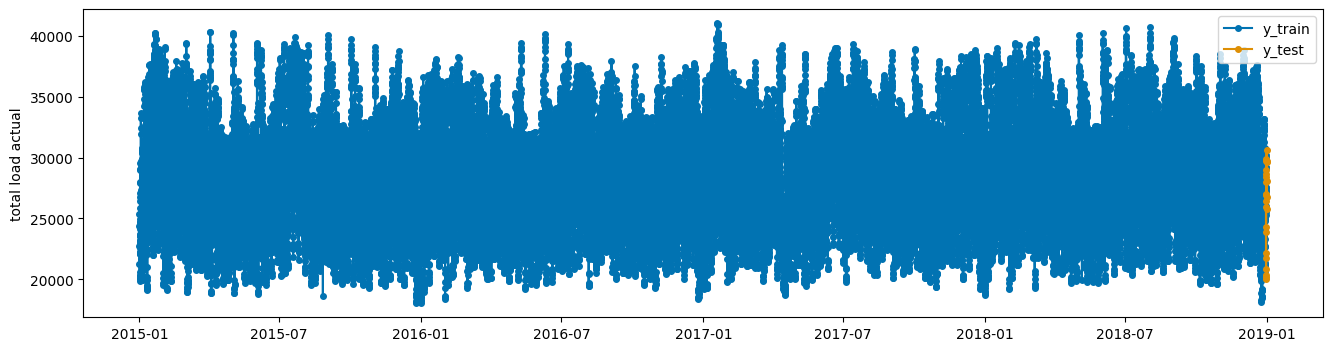

In [5]:
# Temporal train-test split for the analysis & set the test horizon

fh = ForecastingHorizon(arange(1, 25))          # use last 24h for testing purporses
y_train, y_test, X_train, X_test = temporal_train_test_split(y, X, fh=fh, anchor='end')

plot_series(y_train, y_test, labels=['y_train', 'y_test']);

In [6]:
# Create AutoARIMA model (baseline model: univariate forecasting)

model = AutoARIMA(suppress_warnings=True)
model.fit(y_train)

AutoARIMA(suppress_warnings=True)

In [7]:
# Forecast
y_pred = model.predict(fh=fh)
y_pred

2018-12-30 23:00    27890.952194
2018-12-31 00:00    26475.264527
2018-12-31 01:00    25003.497075
2018-12-31 02:00    23770.892071
2018-12-31 03:00    23038.804520
2018-12-31 04:00    22967.974866
2018-12-31 05:00    23558.840541
2018-12-31 06:00    24643.214882
2018-12-31 07:00    25925.350369
2018-12-31 08:00    27059.221566
2018-12-31 09:00    27740.214197
2018-12-31 10:00    27786.104957
2018-12-31 11:00    27185.390393
2018-12-31 12:00    26099.939250
2018-12-31 13:00    24821.267199
2018-12-31 14:00    23692.191258
2018-12-31 15:00    23014.892224
2018-12-31 16:00    22970.027348
2018-12-31 17:00    23568.537951
2018-12-31 18:00    24649.003922
2018-12-31 19:00    25921.175436
2018-12-31 20:00    27043.941914
2018-12-31 21:00    27716.793488
2018-12-31 22:00    27760.251583
Freq: h, Name: total load actual, dtype: float64

MAPE score is 10.69%


(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'A week of energy consumption'}, ylabel='total load actual'>)

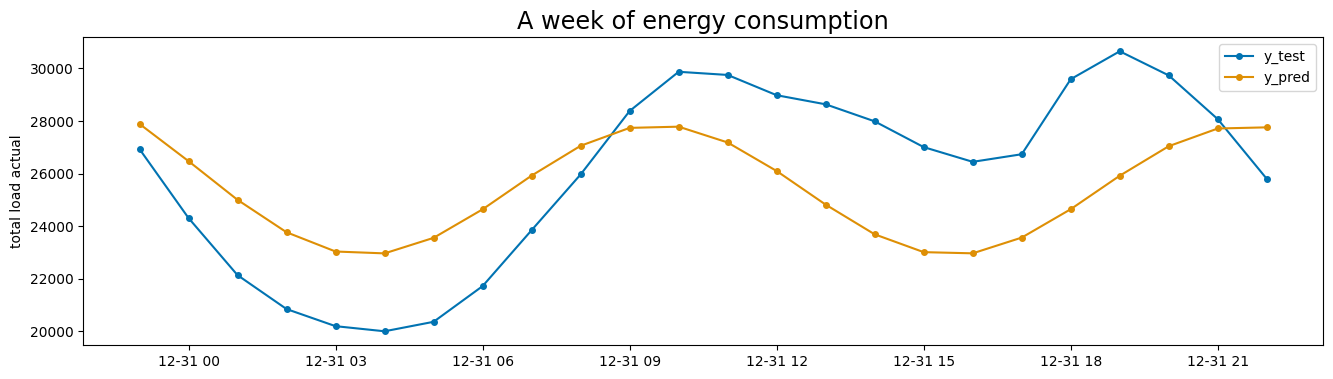

In [8]:
# Plot predicted test samples

print(f"MAPE score is {100*mean_absolute_percentage_error(y_test, y_pred):.2f}%")        # 10.79% error in a day estimate
plot_series(y_test, y_pred, labels=['y_test', 'y_pred'], title='A week of energy consumption')

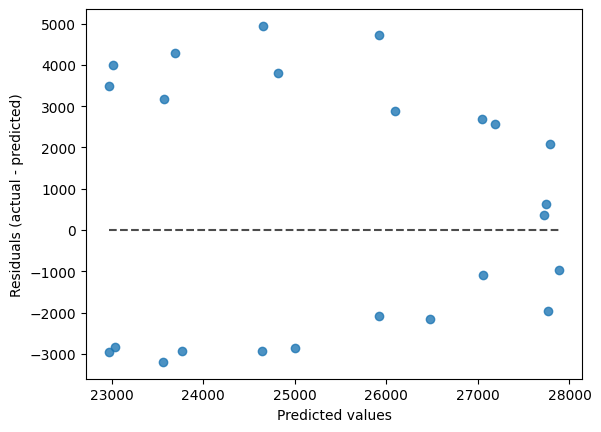

In [9]:
# Check the distribution of errors across the timeseries
PredictionErrorDisplay(y_true=y_test, y_pred=y_pred).plot()         # largely over-predicting consumption in the beginning of the series

In [10]:
# Create AutoARIMA model with exog variables (Multivariate forecasting)

model.fit(y=y_train, X=X_train)

AutoARIMA(suppress_warnings=True)

In [14]:
# Predictions
y_pred = model.predict(fh=fh, X=X_test)

In [15]:
y_pred

2018-12-30 23:00    27864.336997
2018-12-31 00:00    26097.439613
2018-12-31 01:00    24362.137431
2018-12-31 02:00    23122.801114
2018-12-31 03:00    22585.701412
2018-12-31 04:00    22432.270999
2018-12-31 05:00    23120.041366
2018-12-31 06:00    24524.898080
2018-12-31 07:00    25956.916172
2018-12-31 08:00    27294.161818
2018-12-31 09:00    28937.767481
2018-12-31 10:00    30181.807538
2018-12-31 11:00    30888.377576
2018-12-31 12:00    30422.006533
2018-12-31 13:00    29445.202640
2018-12-31 14:00    28768.421667
2018-12-31 15:00    27981.216347
2018-12-31 16:00    27620.912507
2018-12-31 17:00    27880.439265
2018-12-31 18:00    29603.281440
2018-12-31 19:00    30914.858508
2018-12-31 20:00    30220.410548
2018-12-31 21:00    29143.766678
2018-12-31 22:00    27836.628800
Freq: h, Name: total load actual, dtype: float64

MAPE score is 5.83%


(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'A week of energy consumption'}, ylabel='total load actual'>)

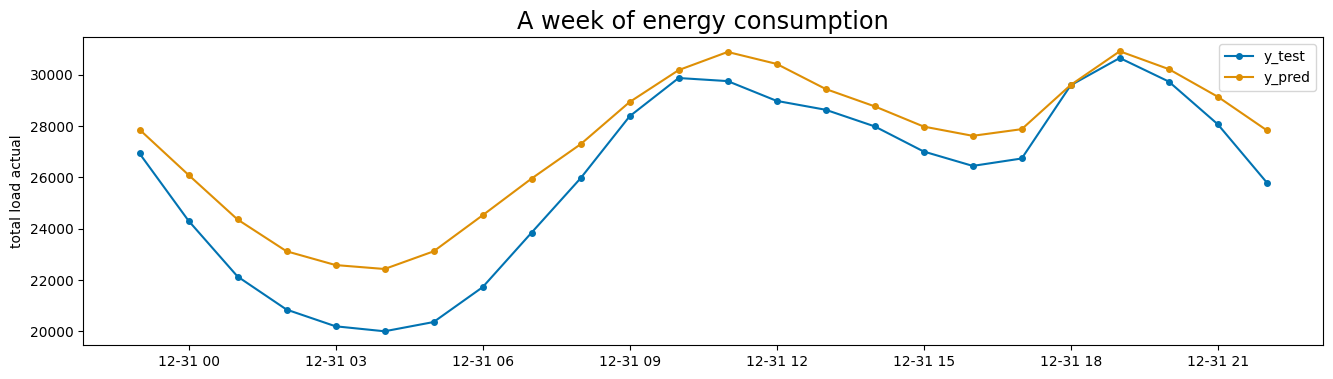

In [16]:
# Plot predicted test samples (model prepared with exog variables)

print(f"MAPE score is {100*mean_absolute_percentage_error(y_test, y_pred):.2f}%")        # 10.79% error in a day estimate
plot_series(y_test, y_pred, labels=['y_test', 'y_pred'], title='A week of energy consumption')

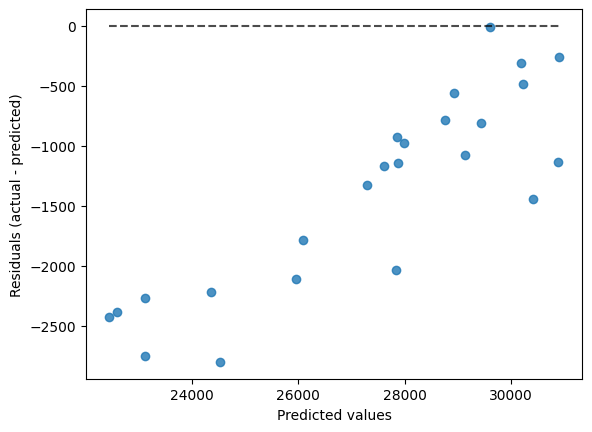

In [17]:
# Check the distribution of errors across the timeseries
PredictionErrorDisplay(y_true=y_test, y_pred=y_pred).plot()         # largely over-predicting consumption in the beginning of the series

In [11]:
# So, how do univariate & multivariate forecast compare?
# Is it worth the trouble to include exog variables?